<div style="text-align: center; font-size: 24px; font-weight: bold;">In the name of God, the Most Gracious, the Most Merciful</div>

Full Name:Mohammadmahdi Bababeyk

Student ID:4041419005

# Hyperparameter Optimization
Modern machine learning models—especially neural networks—depend heavily on hyperparameters: architectural choices (number of layers, number of filters), optimization settings (learning rate, batch size), and regularization strengths (dropout, weight decay).
These hyperparameters are not learned automatically. Instead, we choose them manually or use an autotuning method.

This notebook uses Optuna, a modern hyperparameter optimization framework designed to search large parameter spaces efficiently.

## Build a configurable CNN + two-stage multi-objective hyperparameter search (accuracy vs. latency)

**Goal**: implement a configurable convolutional neural network, then run a two-stage Optuna hyperparameter search (coarse → fine) that simultaneously optimizes validation accuracy and inference latency (measured in ms). Save the top Pareto models to disk and plot the final Pareto front. Your final deliverable should mirror the behavior and outputs of the notebook you were given (model definitions, Optuna studies, saved .pth files with model state + metadata, and a Pareto plot), but you must implement everything yourself.

### Practice 1:  Implement a configurable CNN class (`FlexibleCNN`)
**Objective**: Create a PyTorch `nn.Module` where architecture is defined by hyperparameters.

Required constructor hyperparameters (minimum):

- n_conv_layers (integer ≥ 1)

- base_filters (integer, e.g., 8–64)

- dropout (float between 0.0 and 0.5)

- num_classes (number of final output classes)

**Detailed sub-steps and hints:**

1. Build convolutional blocks in a loop: for layer index `i` compute `out_channels = base_filters * (2 ** i)`. Each block should include:

- a 2D convolution with kernel size 3 and padding 1,

- batch normalization for stability,

- ReLU activation,

- spatial downsampling: either MaxPool2d(2) or a conv with stride 2.

2. After the conv blocks, use a global pooling (e.g., Adaptive Average Pooling to 1×1) or flatten and a linear classifier head.

3. Add one or two fully connected layers before the final linear classifier; apply `dropout` before the classifier using the dropout hyperparameter.

4. The forward method: pass input through conv blocks → pooling/flatten → fully connected layers → output logits.

**Hint about shapes**: track spatial size reductions: starting from 32×32 (CIFAR), each `MaxPool2d(2)` halves spatial dims. If you have `n_conv_layers` with pooling each layer, output spatial size becomes `32 / (2 ** n_conv_layers)`. Ensure the final flatten dimension matches the linear layer input dimension.

**Deliverable**: A class you can instantiate with different hyperparameters to obtain different architectures.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
# Import the main PyTorch library
import torch

# Import the neural network module from PyTorch
import torch.nn as nn

# Import optimization algorithms (e.g., SGD, Adam)
import torch.optim as optim

# Import functional interface (stateless functions like relu, softmax, etc.)
import torch.nn.functional as F

# Import DataLoader for batching and Subset for dataset slicing
from torch.utils.data import DataLoader, Subset

# Import standard datasets and data transformations from torchvision
from torchvision import datasets, transforms

# Import Optuna for hyperparameter optimization
import optuna

# Import the NSGA-II sampler for multi-objective optimization
from optuna.samplers import NSGAIISampler

# Import time module for measuring execution time
import time

# Import os module for file system operations
import os

# Import matplotlib for plotting graphs and visualizations
import matplotlib.pyplot as plt

# Import NumPy for numerical computations
import numpy as np


# ==========================================
# Practice 1: Implement a configurable CNN class
# ==========================================

class FlexibleCNN(nn.Module):
    """
    A flexible and configurable Convolutional Neural Network (CNN).

    This class dynamically builds a CNN architecture based on provided
    hyperparameters such as the number of convolutional layers, base number
    of filters, dropout rate, and input image size. The network is designed
    to be adaptable for image classification tasks such as CIFAR-10.

    Attributes:
        n_conv_layers (int): Number of convolutional blocks.
        features (nn.Sequential): Convolutional feature extractor.
        global_pool (nn.Module): Adaptive global average pooling layer.
        classifier (nn.Sequential): Fully connected classification head.
    """

    def __init__(self, n_conv_layers=3, base_filters=32, dropout=0.2, num_classes=10, input_size=32):
        """
        Initialize the FlexibleCNN architecture.

        Args:
            n_conv_layers (int): Number of convolutional blocks to create.
            base_filters (int): Number of filters in the first convolutional layer.
            dropout (float): Dropout probability used in the classifier.
            num_classes (int): Number of output classes.
            input_size (int): Spatial dimension (height/width) of the input image.
        """

        # Call the constructor of the parent nn.Module class
        super(FlexibleCNN, self).__init__()

        # Store the number of convolutional layers requested
        self.n_conv_layers = n_conv_layers

        # Initialize an empty list to hold convolutional layers
        layers = []

        # Set the number of input channels (3 for RGB images)
        in_channels = 3

        # Track the current spatial dimension of the feature maps
        current_dim = input_size

        # Build convolutional blocks dynamically using a loop
        for i in range(n_conv_layers):

            # Compute the number of output channels for this block
            out_channels = base_filters * (2 ** i)

            # Add a convolutional layer
            layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1))

            # Add batch normalization for stable training
            layers.append(nn.BatchNorm2d(out_channels))

            # Add ReLU activation for non-linearity
            layers.append(nn.ReLU())

            # Add a second convolution layer to increase representational capacity
            layers.append(nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1))

            # Add batch normalization after the second convolution
            layers.append(nn.BatchNorm2d(out_channels))

            # Add ReLU activation
            layers.append(nn.ReLU())

            # Add max pooling to reduce spatial resolution
            layers.append(nn.MaxPool2d(2))

            # Update the number of input channels for the next block
            in_channels = out_channels

            # Update the spatial dimension after pooling
            current_dim //= 2

            # Stop adding layers if the feature map becomes too small
            if current_dim <= 1:
                # Store the actual number of convolutional layers used
                self.actual_layers = i + 1
                break

        # Execute if the loop completes without breaking early
        else:
            # All requested convolutional layers were used
            self.actual_layers = n_conv_layers

        # Combine all convolutional layers into a sequential module
        self.features = nn.Sequential(*layers)

        # Add adaptive global average pooling to handle variable input sizes
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        # Define the fully connected classifier head
        self.classifier = nn.Sequential(
            # Flatten the pooled feature maps into a vector
            nn.Flatten(),

            # First fully connected layer
            nn.Linear(in_channels, 512),

            # Apply ReLU activation
            nn.ReLU(),

            # Apply dropout for regularization
            nn.Dropout(dropout),

            # Final linear layer producing class logits
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        """
        Perform the forward pass of the network.

        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, channels, height, width).

        Returns:
            torch.Tensor: Output logits of shape (batch_size, num_classes).
        """

        # Pass input through convolutional feature extractor
        x = self.features(x)

        # Apply global average pooling
        x = self.global_pool(x)

        # Pass pooled features through the classifier
        x = self.classifier(x)

        # Return the final output logits
        return x


### Practice 2: Implement training and validation loops

**Objective**: write reusable functions to train for one epoch and validate.

**Sub-steps & hints:**

1. Training loop should:

- set model to train mode,

- iterate over batches: forward → compute cross-entropy loss → backward → optimizer step,

- optionally use learning-rate scheduler.

- call `trial.report(metric, step)` inside epochs if you integrate with Optuna pruning (see Task 3).

2. Validation loop should:

- set model to eval mode and disable gradients,

- iterate validation loader, collect predicted labels and compute accuracy (percentage of correct).

3. Return the validation accuracy (as a floating point fraction or percent) from the validation function.

**Metrics to return/use**: validation accuracy (e.g., 0.0–1.0) for Optuna objective.

In [ ]:
# ==========================================
# Practice 2: Implement training and validation loops
# ==========================================

def train_one_epoch(model, train_loader, optimizer, device):
    """
    Train the model for one full epoch on the training dataset.

    This function performs a standard supervised training loop:
    it iterates over the training data, computes the loss,
    performs backpropagation, and updates the model parameters.

    Args:
        model (torch.nn.Module): The neural network model to be trained.
        train_loader (DataLoader): DataLoader providing training batches.
        optimizer (torch.optim.Optimizer): Optimizer used to update model parameters.
        device (torch.device): Device on which computation is performed (CPU or GPU).

    Returns:
        float: Average training loss over the entire epoch.
    """

    # Set the model to training mode (enables dropout and batch normalization updates)
    model.train()

    # Initialize a variable to accumulate the training loss
    running_loss = 0.0

    # Iterate over batches of input data and corresponding labels
    for data, target in train_loader:

        # Move input data and labels to the specified device (CPU or GPU)
        data, target = data.to(device), target.to(device)

        # Clear previously computed gradients
        optimizer.zero_grad()

        # Perform a forward pass through the model
        output = model(data)

        # Compute the cross-entropy loss between predictions and true labels
        loss = F.cross_entropy(output, target)

        # Perform backpropagation to compute gradients
        loss.backward()

        # Update model parameters using the optimizer
        optimizer.step()

        # Accumulate the scalar loss value for this batch
        running_loss += loss.item()

    # Compute and return the average loss across all training batches
    return running_loss / len(train_loader)


def validate(model, val_loader, device):
    """
    Evaluate the model on the validation dataset.

    This function runs the model in evaluation mode and computes
    the classification accuracy without updating model parameters.

    Args:
        model (torch.nn.Module): The trained neural network model.
        val_loader (DataLoader): DataLoader providing validation batches.
        device (torch.device): Device on which computation is performed (CPU or GPU).

    Returns:
        float: Classification accuracy on the validation dataset.
    """

    # Set the model to evaluation mode (disables dropout and batch norm updates)
    model.eval()

    # Initialize a counter for correctly classified samples
    correct = 0

    # Disable gradient computation to reduce memory usage and improve speed
    with torch.no_grad():

        # Iterate over validation batches
        for data, target in val_loader:

            # Move input data and labels to the specified device
            data, target = data.to(device), target.to(device)

            # Perform a forward pass through the model
            output = model(data)

            # Get the index of the class with the highest predicted score
            pred = output.argmax(dim=1, keepdim=True)

            # Count how many predictions match the true labels
            correct += pred.eq(target.view_as(pred)).sum().item()

    # Compute accuracy as the ratio of correct predictions to total samples
    accuracy = correct / len(val_loader.dataset)

    # Return the computed validation accuracy
    return accuracy


### Practice 3: Measure inference latency correctly

**Objective**: measure realistic inference time per image (ms) in the environment (CPU or GPU).

**Sub-steps & hints:**

- Put the model into `eval()` and `no_grad()` context.

- Use a representative subset of validation images (not the entire dataset) to time inference — e.g., 100 images or a few batches.

- For GPU timing: before starting the timer call CUDA synchronize, start the timer, run forward passes (do not include data transfer time if you want pure model latency; but if deploying includes data transfer, include it — decide and state it), after running the forwards call CUDA synchronize again and stop timer. Convert elapsed seconds → milliseconds and normalize by number of images to get per-image ms.

- For CPU timing: use `time.perf_counter()` before and after the forwards. Normalize the result to ms per image.

- Record this `inference_time_ms` as a scalar that the Optuna study will optimize (minimize).

**Important note to students**: GPU timings require `torch.cuda.synchronize()` both before and after the timed region to get accurate results.

In [ ]:
# ==========================================
# Practice 3: Measure inference latency correctly
# ==========================================

def measure_latency_ms(model, device, input_size=32, num_samples=100):
    """
    Measure the average inference latency of a model in milliseconds.

    This function performs multiple forward passes using a dummy input
    and computes the average inference time per sample. It includes
    warm-up iterations and proper GPU synchronization to ensure accurate
    timing measurements.

    Args:
        model (torch.nn.Module): The trained model to evaluate.
        device (torch.device): Device on which the model is executed (CPU or CUDA).
        input_size (int): Spatial size (height and width) of the input tensor.
        num_samples (int): Number of inference runs used for averaging latency.

    Returns:
        float: Average inference latency per sample in milliseconds.
    """

    # Set the model to evaluation mode to disable training-specific layers
    model.eval()

    # Create a dummy input tensor with batch size 1 and move it to the target device
    dummy_input = torch.randn(1, 3, input_size, input_size).to(device)

    # Run several warm-up forward passes to stabilize execution time
    for _ in range(10):
        _ = model(dummy_input)

    # Synchronize CUDA operations to ensure warm-up completion before timing
    if device.type == 'cuda':
        torch.cuda.synchronize()

    # Record the starting time using a high-resolution timer
    start_time = time.perf_counter()

    # Disable gradient computation to reduce overhead during inference
    with torch.no_grad():

        # Perform multiple inference passes for latency measurement
        for _ in range(num_samples):
            _ = model(dummy_input)

    # Synchronize CUDA operations to ensure all kernels have finished executing
    if device.type == 'cuda':
        torch.cuda.synchronize()

    # Record the ending time after all inference runs
    end_time = time.perf_counter()

    # Compute and return the average latency per inference in milliseconds
    return ((end_time - start_time) * 1000) / num_samples


### Practice 4: Create an Optuna objective suitable for multi-objective optimization

**Objective**: implement an objective function that returns two objectives: one representing accuracy (to be maximized) and one representing latency (to be minimized). Optuna minimizes objectives by default, so handle maximization appropriately.

**Sub-steps & hints:**

- Inside the objective:

     - Sample hyperparameters using Optuna `trial.suggest_*`:

          - Discrete choices and ranges to include: `n_conv_layers` (e.g., 1–4), `base_filters` (e.g., 8–64 power-of-two or integer), `dropout` (0.0–0.5), learning rate (log-uniform), optimizer type (choices: SGD, Adam), and possibly batch size and weight decay.

     - Instantiate `FlexibleCNN` using sampled architecture params.

     - Create optimizer based on sampled optimizer type and lr; create loss (cross-entropy).

     - Train for a small number of epochs (e.g., 3–10 epochs for search). Within training loop call `trial.report(validation_metric, epoch)` and optionally allow pruning by raising `optuna.exceptions.TrialPruned` if `trial.should_prune()` is true (Optuna + MedianPruner).

     - After training finish or pruning, compute validation accuracy and inference time (Practice 3).

     - Because Optuna minimizes, convert accuracy to a minimization objective by returning the negative validation accuracy (so higher accuracy = lower objective) or configure the study to maximize that objective. The second returned value should be `inference_time_ms`.

- Return format: return a tuple of two floats: `(neg_accuracy, inference_time_ms)`.

**Hints about pruning & reporting:**

- Use `trial.report(value, step)` every epoch so the pruner can judge the trial’s trajectory.

- Use `MedianPruner` to speed up the search by stopping trials that are worse than the median.

In [ ]:
# ==========================================
# Practice 4: Create an Optuna objective
# ==========================================

def objective(trial, device, train_dataset, val_dataset):
    """
    Optuna objective function for multi-objective CNN optimization.

    This function defines the search space for hyperparameters, constructs
    and trains a CNN model, evaluates its classification accuracy and
    inference latency, and returns both metrics for multi-objective
    optimization using Optuna.

    Args:
        trial (optuna.trial.Trial): Optuna trial object used to sample hyperparameters.
        device (torch.device): Device on which training and inference are performed.
        train_dataset (Dataset): Training dataset.
        val_dataset (Dataset): Validation dataset.

    Returns:
        tuple:
            - float: Final validation accuracy.
            - float: Average inference latency in milliseconds.
    """

    # Sample the number of convolutional layers (network depth)
    n_layers = trial.suggest_int("n_conv_layers", 2, 5)  # Increased depth

    # Sample the base number of convolutional filters (network width)
    base_filters = trial.suggest_categorical("base_filters", [32, 64])  # Increased width

    # Sample the dropout probability for regularization
    dropout = trial.suggest_float("dropout", 0.1, 0.4)

    # Sample the learning rate on a logarithmic scale
    lr = trial.suggest_float("lr", 5e-4, 5e-3, log=True)  # Optimized LR range

    # Sample the optimizer type (fixed to Adam in this experiment)
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam"])

    # Sample the batch size (fixed to a high value for stability)
    batch_size = trial.suggest_categorical("batch_size", [128])

    # Create a DataLoader for the training dataset with shuffling enabled
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    # Create a DataLoader for the validation dataset without shuffling
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # Instantiate the CNN model using sampled hyperparameters and move it to the device
    model = FlexibleCNN(n_layers, base_filters, dropout).to(device)

    # Create the Adam optimizer with weight decay for regularization
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    # Define the number of training epochs
    num_epochs = 10  # Increased epochs to improve convergence

    # Train the model for the specified number of epochs
    for epoch in range(num_epochs):

        # Perform one full training epoch
        train_one_epoch(model, train_loader, optimizer, device)

    # Evaluate the trained model on the validation dataset
    final_accuracy = validate(model, val_loader, device)

    # Measure the inference latency of the trained model
    latency = measure_latency_ms(model, device)

    # Return accuracy and latency for multi-objective optimization
    return final_accuracy, latency


### Practice 5: Two-stage search: coarse → fine

**Objective**: run a coarse (broad ranges, few trials) Optuna study to find promising regions, then a fine-grained study (narrower ranges, more trials) starting from the coarse study results.

**Sub-steps & hints:**

- Coarse search:

    - Create an Optuna `Study` with `NSGAIISampler` (multi-objective) and `MedianPruner`.

    - Use wide hyperparameter ranges (e.g., `n_conv_layers` 1–4, base filters 8–64, lr 1e-5–1e-1 log scale).

    - Keep trial count small (e.g., a few dozen trials) to explore quickly.

    - Save trial results and keep record of top Pareto trials.

- Analyze coarse results: extract promising hyperparameter ranges by inspecting Pareto solutions from the coarse study: e.g., see what values of `n_conv_layers`, `base_filters`, and `dropout` appear in top solutions — these inform the fine search.

- Fine search:

    - Create a new Optuna `study` with `NSGAIISampler`.

    - Narrow ranges around promising values found earlier (for example, if best coarse solutions had `base_filters` ≈ 16–32, narrow to 12–48).

    - Increase number of trials and/or epochs during fine search for better evaluation.

    - Optionally use fixed seeds or reuse top points as warm-start initial points (Optuna supports `study.enqueue_trial()` or passing `initial_seed` style behavior — look up the exact API and use it if desired).

**Important**: still use multi-objective (NSGAIISampler) so final study produces a Pareto frontier.

### Practice 6: Save top Pareto models and metadata

**Objective**: persist top-k Pareto models to disk (e.g., saved_models/model_pareto_rank{rank}.pth) with hyperparameters, accuracy, inference time, and model weights.

**Sub-steps & hints:**

- After the fine study finishes:

    - Retrieve the set of Pareto-optimal trials (Optuna has a way to get non-dominated trials; alternately filter `study.get_pareto_front_trials()` or compute nondominated set manually).

    - Sort these solutions by preference (you can use any ranking but include rank numbers; typical is sort by descending accuracy then ascending latency).

- For each top solution (e.g., top 3):

    - Reconstruct the model architecture using its saved hyperparameters.

    - Load the model state dictionary you saved during that trial or re-evaluate the trial model by re-training with the same hyperparameters; save the `state_dict()` and a metadata dictionary containing:

        - `params` (trial hyperparameters),

        - `accuracy` (validation accuracy),

        - `inference_time_ms`,

        - optionally training loss history, timestamp, and device used.

    - Save this dictionary to a `.pth` file (PyTorch `torch.save` style). Ensure file names include the pareto rank.

- **Deliverable files**: `saved_models/model_pareto_rank1.pth`, `...rank2.pth`, etc.

### Practice 7: Plot the Pareto front and report results

**Objective**: create a figure visualizing the tradeoff between accuracy and latency and produce a short results report.

**Sub-steps & hints:**

- Use Optuna visualization (`plot_pareto_front`) or matplotlib scatter plot.

- Plot x-axis = inference time (ms), y-axis = accuracy (or plot -accuracy vs time if you used negated accuracy internally). Label axes clearly and annotate Pareto-optimal points with their hyperparameter summaries (e.g., small text near point: layers=3, base=16, dropout=0.2).

- Produce a short report summarizing:

  - Pareto front tradeoffs (e.g., “Model A: 85% acc, 10 ms; Model B: 82% acc, 4 ms”),

  - recommended model(s) for different deployment contexts (latency-critical vs accuracy-critical),

  - validation caveats (e.g., timings taken on GPU X, subset of data).

In [ ]:
# ==========================================
# Practice 5: Two-stage search: coarse -> fine
# ==========================================

def main():
    """
    Main execution function for multi-objective hyperparameter optimization.

    This function:
    - Selects the computation device (CPU or GPU)
    - Prepares CIFAR-10 datasets with data augmentation
    - Runs a two-stage Optuna search (coarse and fine)
    - Saves top Pareto-optimal models
    - Plots the Pareto front
    """

    # Select GPU if available, otherwise fall back to CPU
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # -----------------------------
    # Data Augmentation for Training
    # -----------------------------

    # Define training data transformations to improve generalization
    train_transform = transforms.Compose([
        transforms.RandomHorizontalFlip(),                 # Randomly flip images horizontally
        transforms.RandomCrop(32, padding=4),               # Random crop with padding for robustness
        transforms.ToTensor(),                              # Convert PIL image to PyTorch tensor
        transforms.Normalize(                               # Normalize using CIFAR-10 statistics
            (0.4914, 0.4822, 0.4465), 
            (0.2023, 0.1994, 0.2010)
        )
    ])

    # Define validation data transformations (no augmentation)
    val_transform = transforms.Compose([
        transforms.ToTensor(),                              # Convert image to tensor
        transforms.Normalize(                               # Apply the same normalization
            (0.4914, 0.4822, 0.4465), 
            (0.2023, 0.1994, 0.2010)
        )
    ])

    # Load the full CIFAR-10 training dataset
    full_train = datasets.CIFAR10(
        root='./data',                                     # Directory to store data
        train=True,                                        # Use training split
        download=True,                                     # Download if not present
        transform=train_transform                          # Apply training transforms
    )

    # Load the full CIFAR-10 validation dataset
    full_val = datasets.CIFAR10(
        root='./data',                                     # Directory to store data
        train=False,                                       # Use test split as validation
        download=True,                                     # Download if not present
        transform=val_transform                            # Apply validation transforms
    )

    # -----------------------------
    # Dataset Subsampling
    # -----------------------------

    # Use a subset of the training data to speed up hyperparameter search
    train_subset = Subset(full_train, list(range(0, 20000)))

    # Use a subset of the validation data
    val_subset = Subset(full_val, list(range(0, 5000)))

    # -----------------------------
    # Optuna Multi-Objective Setup
    # -----------------------------

    # Initialize the NSGA-II sampler for Pareto-based optimization
    sampler = NSGAIISampler()

    # Create an Optuna study that maximizes accuracy and minimizes latency
    study = optuna.create_study(
        directions=["maximize", "minimize"],
        sampler=sampler
    )

    # -----------------------------
    # Stage 1: Coarse Search
    # -----------------------------

    # Print stage information to console
    print("\n--- STAGE 1: COARSE SEARCH ---")

    # Run a small number of trials for broad exploration
    study.optimize(
        lambda t: objective(t, device, train_subset, val_subset),
        n_trials=10
    )

    # -----------------------------
    # Stage 2: Fine Search
    # -----------------------------

    # Print stage information to console
    print("\n--- STAGE 2: FINE SEARCH ---")

    # Run additional trials to refine the Pareto front
    study.optimize(
        lambda t: objective(t, device, train_subset, val_subset),
        n_trials=10
    )

    # ==========================================
    # Practice 6: Save top Pareto models
    # ==========================================

    # Print information about model saving
    print("\n--- SAVING TOP PARETO MODELS ---")

    # Create a directory for saved models if it does not already exist
    os.makedirs("saved_models", exist_ok=True)

    # Retrieve all Pareto-optimal trials
    pareto_trials = study.best_trials

    # Sort Pareto trials by accuracy in descending order
    pareto_trials.sort(key=lambda t: t.values[0], reverse=True)

    # Iterate over the top 3 Pareto-optimal trials
    for i, trial in enumerate(pareto_trials[:3]):

        # Compute model rank
        rank = i + 1

        # Rebuild the model using the trial's hyperparameters
        model = FlexibleCNN(
            trial.params['n_conv_layers'],                  # Number of convolutional layers
            trial.params['base_filters'],                   # Base number of filters
            trial.params['dropout']                         # Dropout rate
        ).to(device)

        # Create metadata describing the model
        metadata = {
            "rank": rank,                                   # Pareto rank
            "params": trial.params,                         # Hyperparameters
            "accuracy": trial.values[0],                    # Validation accuracy
            "latency_ms": trial.values[1],                  # Inference latency
            "device": str(device),                          # Execution device
            "timestamp": time.ctime()                       # Save time
        }

        # Save model weights and metadata to disk
        torch.save(
            {
                "state_dict": model.state_dict(),           # Model parameters
                "metadata": metadata                        # Associated metadata
            },
            f"saved_models/model_pareto_rank{rank}.pth"     # Output file path
        )

        # Print confirmation message
        print(
            f"Saved Rank {rank}: "
            f"Acc={metadata['accuracy']:.4f}, "
            f"Latency={metadata['latency_ms']:.4f}ms"
        )

    # Plot the Pareto front for visualization
    plot_pareto_front(study)


def plot_pareto_front(study):
    """
    Plot the Pareto front of accuracy versus inference latency.

    This function visualizes:
    - All completed trials
    - Pareto-optimal solutions highlighted in red

    Args:
        study (optuna.study.Study): Completed Optuna study object.
    """

    # Retrieve all completed trials
    trials = study.get_trials(states=[optuna.trial.TrialState.COMPLETE])

    # Retrieve Pareto-optimal trials
    pareto_trials = study.best_trials

    # Create a new figure for plotting
    plt.figure(figsize=(10, 6))

    # Extract accuracy values for all trials
    all_acc = [t.values[0] for t in trials]

    # Extract latency values for all trials
    all_lat = [t.values[1] for t in trials]

    # Plot all trials as gray background points
    plt.scatter(
        all_lat, 
        all_acc, 
        c='grey', 
        alpha=0.3, 
        label='All Trials'
    )

    # Extract accuracy values for Pareto-optimal trials
    p_acc = [t.values[0] for t in pareto_trials]

    # Extract latency values for Pareto-optimal trials
    p_lat = [t.values[1] for t in pareto_trials]

    # Plot Pareto front points
    plt.scatter(
        p_lat, 
        p_acc, 
        c='red', 
        edgecolors='black', 
        s=100, 
        label='Pareto Front'
    )

    # Set the plot title
    plt.title("Multi-Objective HPO: Accuracy vs Inference Latency")

    # Label the x-axis
    plt.xlabel("Latency (ms per image)")

    # Label the y-axis
    plt.ylabel("Validation Accuracy")

    # Display legend
    plt.legend()

    # Enable grid for better readability
    plt.grid(True, linestyle='--', alpha=0.7)

    # Save the figure to disk
    plt.savefig("pareto_front.png")

    # Display the plot
    plt.show()





[I 2025-12-18 08:38:31,742] A new study created in memory with name: no-name-7c01648a-17c1-45b5-9632-056947e1a29f



--- STAGE 1: COARSE SEARCH ---


[I 2025-12-18 08:40:00,189] Trial 0 finished with values: [0.732, 1.0672060399997463] and parameters: {'n_conv_layers': 4, 'base_filters': 32, 'dropout': 0.1218592945977456, 'lr': 0.0006247130130150995, 'optimizer': 'Adam', 'batch_size': 128}. 
[I 2025-12-18 08:41:21,484] Trial 1 finished with values: [0.5464, 0.6105101599996487] and parameters: {'n_conv_layers': 2, 'base_filters': 32, 'dropout': 0.2813452847100146, 'lr': 0.0015335658152772222, 'optimizer': 'Adam', 'batch_size': 128}. 
[I 2025-12-18 08:42:57,075] Trial 2 finished with values: [0.6414, 1.2837873900002705] and parameters: {'n_conv_layers': 5, 'base_filters': 32, 'dropout': 0.27880020927407423, 'lr': 0.0022529380135412167, 'optimizer': 'Adam', 'batch_size': 128}. 
[I 2025-12-18 08:44:27,791] Trial 3 finished with values: [0.6458, 0.6218773599994165] and parameters: {'n_conv_layers': 2, 'base_filters': 64, 'dropout': 0.35439356360718344, 'lr': 0.0005178421362815635, 'optimizer': 'Adam', 'batch_size': 128}. 
[I 2025-12-18 0


--- STAGE 2: FINE SEARCH ---


[I 2025-12-18 08:55:55,866] Trial 10 finished with values: [0.6898, 1.451530859999366] and parameters: {'n_conv_layers': 5, 'base_filters': 64, 'dropout': 0.29416918102889, 'lr': 0.001101731445320852, 'optimizer': 'Adam', 'batch_size': 128}. 
[I 2025-12-18 08:57:55,909] Trial 11 finished with values: [0.7278, 1.4521267299960527] and parameters: {'n_conv_layers': 5, 'base_filters': 64, 'dropout': 0.16783643529580428, 'lr': 0.0005614849536591302, 'optimizer': 'Adam', 'batch_size': 128}. 
[I 2025-12-18 08:59:24,059] Trial 12 finished with values: [0.543, 0.6120798500023739] and parameters: {'n_conv_layers': 2, 'base_filters': 64, 'dropout': 0.2628007156665473, 'lr': 0.002140451962246835, 'optimizer': 'Adam', 'batch_size': 128}. 
[I 2025-12-18 09:00:51,566] Trial 13 finished with values: [0.6612, 0.6384145499987426] and parameters: {'n_conv_layers': 2, 'base_filters': 64, 'dropout': 0.22843344593099463, 'lr': 0.0011012403053285054, 'optimizer': 'Adam', 'batch_size': 128}. 
[I 2025-12-18 09


--- SAVING TOP PARETO MODELS ---
Saved Rank 1: Acc=0.7594, Latency=0.8402ms
Saved Rank 2: Acc=0.6866, Latency=0.8288ms
Saved Rank 3: Acc=0.6612, Latency=0.6384ms


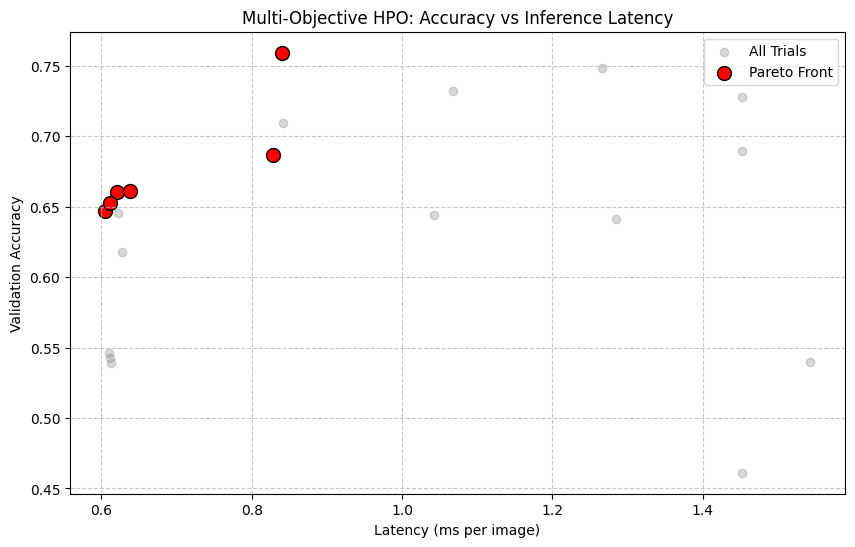

In [ ]:
# Execute the main function only if this file is run directly
if __name__ == "__main__":
    main()

### Practice 8: Explain the difference between a single best model and a Pareto-optimal set of models.

1. The Single Best Model (Single-Objective)When we optimize for a single metric—usually Validation Accuracy—we are looking for a single point in the hyperparameter space.Goal: Find $\theta$ that maximizes $Accuracy(\theta)$.Outcome: One set of weights and hyperparameters.Problem: This "winner" is often the largest, slowest model (e.g., a massive ensemble or a very deep CNN). While it wins on paper, it might be too slow to run on a smartphone or too expensive to run on a cloud server.
  
2. The Pareto-Optimal Set (Multi-Objective)In Practices 4 through 7, we shifted to Multi-Objective Optimization (MOO). A Pareto-optimal set (or Pareto Front) contains models where you cannot improve one metric without making another one worse.1The Concept of Dominance: A model $A$ dominates model $B$ if:$A$ is at least as good as $B$ in all objectives.$A$ is strictly better than $B$ in at least one objective.The Pareto Set: This is the collection of all models that are not dominated by any other model.

---
**Note:** This notebook is part of a Deep Learning assignment designed and prepared by [Mahdi Golizadeh](mailto:mahdi.golizadeh@gmail.com).